# Survival Analysis: ERBB2 in Lung Adenocarcinoma vs Breast Carcinoma

We compare

- **Cohort A:** `pgx:TCGA-LUAD` (Lung Adenocarcinoma)
- **Cohort B:** `pgx:TCGA-BRCA` (Breast Invasive Carcinoma)

ERBB2 (HER2) is the canonical amplified driver in HER2-positive breast cancer
and an established prognostic and predictive biomarker. In NSCLC the alteration
is rarer and its prognostic role is less clear.

1. Kaplan-Meier curves stratified by ERBB2 CNV status,
2. cohort-specific Cox proportional hazards models (lifelines),
3. progressive adjustments for stage and a 5-year follow-up truncation that
   counter the BRCA early-detection lead-time bias,
4. a focal vs broad gain distinction that better reflects the clinically
   actionable HER2-positive events,
5. a pooled Cox model with a cohort-by-ERBB2 interaction term,
6. and the concordance index (C-index) for discrimination.

## Environment Setup

```bash
conda install -c conda-forge scikit-survival lifelines
pip install scikit-survival lifelines
```

In [2]:
import requests
import io
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.metrics import concordance_index_censored
from lifelines import CoxPHFitter

## Cohort definitions

In [3]:
COHORTS = {
    "LUAD": {
        "filter": "pgx:TCGA-LUAD",
        "label": "Lung Adenocarcinoma",
        "color": "#0D9488",
    },
    "BRCA": {
        "filter": "pgx:TCGA-BRCA",
        "label": "Breast Invasive Carcinoma",
        "color": "#C75146",
    },
}

SAMPLETABLE_URL = "https://progenetix.org/services/sampletable/"

CACHE_DIR = Path("cache_erbb2")
CACHE_DIR.mkdir(exist_ok=True)

JSON_CACHE = CACHE_DIR / "json"
JSON_CACHE.mkdir(parents=True, exist_ok=True)

## HTTP session

In [4]:
SESSION = requests.Session()
SESSION.mount("https://", requests.adapters.HTTPAdapter(
    pool_connections=32, pool_maxsize=32
))
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})


def _cached_get(url, key, params=None, timeout=120):
    p = JSON_CACHE / f"{key}.json"
    if p.exists():
        with p.open() as f:
            return json.load(f)
    r = SESSION.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    with p.open("w") as f:
        json.dump(data, f)
    return data

## Progenetix API helpers

In [5]:
def fetch_sampletable(filters, limit=0, timeout=180):
    """Download a Progenetix sample table for one filter as a DataFrame."""
    r = SESSION.get(
        SAMPLETABLE_URL,
        params={"filters": filters, "limit": limit},
        timeout=timeout,
    )
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep="\t")


def fetch_individual_record(individual_id, timeout=120):
    return _cached_get(
        f"https://progenetix.org/beacon/individuals/{individual_id}/",
        key=f"ind__{individual_id}",
        timeout=timeout,
    )


def fetch_g_variants(biosample_id, timeout=120):
    return _cached_get(
        f"https://progenetix.org/beacon/biosamples/{biosample_id}/g_variants/",
        key=f"cnv__{biosample_id}",
        params={"requestedGranularity": "record"},
        timeout=timeout,
    )

## Parsers for the Progenetix JSON schema

Field paths verified against the live Progenetix Beacon v2 response:

- vital status: `rec["vitalStatus"]["status"]` returns `"ALIVE"` or `"DECEASED"`,
- follow-up days: flat field `disease["followupDays"]`,
- CNV records: `record["variation"]["location"][{chromosome,start,end}]` and
  `record["variation"]["copyChange"]` (string label, e.g. `"high-level gain"`).

In [6]:
def parse_individual_record(data):
    """Flatten one Progenetix individual JSON into a row with survival fields."""
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])
    if not result_sets:
        return None
    results = result_sets[0].get("results", [])
    if not results:
        return None
    rec = results[0]

    diseases = rec.get("diseases", [])
    disease_0 = diseases[0] if diseases else {}

    return {
        "individual_id": rec.get("id"),
        "sex_label_individual": rec.get("sex", {}).get("label"),
        "vital_status": rec.get("vitalStatus", {}).get("status"),
        "info_days_to_death": rec.get("info", {}).get("daysToDeath"),
        "disease_label": disease_0.get("diseaseCode", {}).get("label"),
        "followup_days": disease_0.get("followupDays"),
        "followup_state_label": disease_0.get("followupState", {}).get("label"),
        "stage_label_individual": disease_0.get("stage", {}).get("label"),
    }

In [7]:
ERBB2 = {"chromosome": "17", "start": 39688094, "end": 39728658}

FOCAL_MAX_BP = 3_000_000

def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start <= b_end and b_start <= a_end


def _classify_copy_change(label):
    if not isinstance(label, str):
        return "other"
    x = label.strip().lower()
    if "gain" in x:
        return "gain"
    if "loss" in x:
        return "loss"
    return "other"


def summarize_erbb2(records, gene=ERBB2):
    """Reduce CNV records for one biosample into binary ERBB2 features,
    including a focal vs broad gain distinction (segment length)."""
    feats = {
        "ERBB2_hit": 0,
        "ERBB2_gain_hit": 0,
        "ERBB2_loss_hit": 0,
        "ERBB2_focal_gain": 0,
        "ERBB2_broad_gain": 0,
        "ERBB2_min_gain_seg_bp": np.nan,
    }
    if not records:
        return feats

    g_chr = str(gene["chromosome"])
    g_start, g_end = int(gene["start"]), int(gene["end"])
    gain_seg_lens = []

    for item in records:
        variation = item.get("variation", {})
        loc = variation.get("location", {})
        chrom = str(loc.get("chromosome"))
        start, end = loc.get("start"), loc.get("end")
        if chrom != g_chr or start is None or end is None:
            continue
        if not intervals_overlap(int(start), int(end), g_start, g_end):
            continue

        feats["ERBB2_hit"] = 1
        seg_len = int(end) - int(start)
        state = _classify_copy_change(
            variation.get("copyChange") or variation.get("variantState", {}).get("label")
        )
        if state == "gain":
            feats["ERBB2_gain_hit"] = 1
            gain_seg_lens.append(seg_len)
            if seg_len < FOCAL_MAX_BP:
                feats["ERBB2_focal_gain"] = 1
            else:
                feats["ERBB2_broad_gain"] = 1
        elif state == "loss":
            feats["ERBB2_loss_hit"] = 1

    if gain_seg_lens:
        feats["ERBB2_min_gain_seg_bp"] = min(gain_seg_lens)
    return feats

## Combined parallel fetcher

In [8]:
def fetch_all_parallel(individual_ids, biosample_ids, max_workers=16):
    """Fetch individuals and CNVs concurrently in one thread pool."""
    indiv_rows, indiv_fail = [], []
    cnv_rows, cnv_fail = [], []

    def _ind(iid):
        try:
            return ("ind", iid, parse_individual_record(fetch_individual_record(iid)), None)
        except Exception as e:
            return ("ind", iid, None, str(e))

    def _cnv(bid):
        try:
            data = fetch_g_variants(bid)
            recs = data.get("response", {}).get("resultSets", [{}])[0].get("results", [])
            feats = summarize_erbb2(recs)
            feats["biosample_id"] = bid
            return ("cnv", bid, feats, None)
        except Exception as e:
            return ("cnv", bid, None, str(e))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = []
        for iid in individual_ids:
            futures.append(ex.submit(_ind, iid))
        for bid in biosample_ids:
            futures.append(ex.submit(_cnv, bid))

        for fut in tqdm(as_completed(futures), total=len(futures), desc="fetching"):
            kind, _id, payload, err = fut.result()
            rows = indiv_rows if kind == "ind" else cnv_rows
            fail = indiv_fail if kind == "ind" else cnv_fail
            if err is not None:
                fail.append((_id, err))
            elif payload is None:
                fail.append((_id, "no_result"))
            else:
                rows.append(payload)

    return (pd.DataFrame(indiv_rows), indiv_fail,
            pd.DataFrame(cnv_rows),   cnv_fail)

## End-to-end cohort pipeline

In [9]:
def stage_to_numeric(label):
    """Map TCGA pathological stage labels to integer 1..4. Returns NaN if unknown."""
    if not isinstance(label, str):
        return np.nan
    L = label.upper().replace("STAGE", "").strip()
    if L.startswith("IV"):
        return 4
    if L.startswith("III"):
        return 3
    if L.startswith("II"):
        return 2
    if L.startswith("I"):
        return 1
    return np.nan


def build_cohort_df(name, cohort_filter, max_workers=16, force=False):
    cache = CACHE_DIR / f"{name}_cohort.pkl"
    if cache.exists() and not force:
        print(f"[{name}] loading cached cohort: {cache}")
        return pd.read_pickle(cache)

    print(f"[{name}] downloading sample table for {cohort_filter}")
    samples = fetch_sampletable(cohort_filter, limit=0)
    samples = samples[samples["biosample_status_label"] == "neoplastic sample"].copy()
    samples = samples.dropna(subset=["individual_id"])

    # one biosample per individual, prefer primary tumor
    samples["is_primary"] = samples["notes"].fillna("").str.contains("Primary", case=False).astype(int)
    samples = (samples.sort_values("is_primary", ascending=False)
                      .drop_duplicates(subset=["individual_id"], keep="first"))
    print(f"[{name}] unique analysable biosamples: {len(samples)}")

    individual_ids = samples["individual_id"].tolist()
    biosample_ids  = samples["biosample_id"].tolist()

    indiv_df, indiv_fail, cnv_df, cnv_fail = fetch_all_parallel(
        individual_ids, biosample_ids, max_workers=max_workers
    )
    print(f"[{name}] fetched: individuals={len(indiv_df)} (fail {len(indiv_fail)}), "
          f"CNV={len(cnv_df)} (fail {len(cnv_fail)})")

    merged = (
        samples[["individual_id", "biosample_id", "pathological_stage_label"]]
        .merge(cnv_df, on="biosample_id", how="left")
        .merge(indiv_df, on="individual_id", how="inner")
    )
    for c in ["ERBB2_hit", "ERBB2_gain_hit", "ERBB2_loss_hit",
              "ERBB2_focal_gain", "ERBB2_broad_gain"]:
        merged[c] = merged[c].fillna(0).astype(int)

    merged["event"] = (merged["vital_status"].astype(str).str.upper() == "DECEASED").astype(int)
    merged["time"]  = pd.to_numeric(merged["followup_days"], errors="coerce")
    merged = merged.dropna(subset=["time"])
    merged = merged[merged["time"] > 0].copy()

    # numeric stage from sample-level field, fall back to individual-level if missing
    merged["stage_num"] = merged["pathological_stage_label"].apply(stage_to_numeric)
    fallback = merged["stage_num"].isna() & merged["stage_label_individual"].notna()
    merged.loc[fallback, "stage_num"] = merged.loc[fallback, "stage_label_individual"].apply(stage_to_numeric)

    merged["cohort"] = name

    print(f"[{name}] final analysable individuals: {len(merged)}")
    merged.to_pickle(cache)
    return merged

## Run the pipeline for both cohorts

In [10]:
with ThreadPoolExecutor(max_workers=2) as ex:
    futures = {
        name: ex.submit(build_cohort_df, name, cfg["filter"], max_workers=8)
        for name, cfg in COHORTS.items()
    }
    cohort_dfs = {name: fut.result() for name, fut in futures.items()}

for name, df in cohort_dfs.items():
    print(f"{name}: n={len(df)}, events={df['event'].sum()}, "
          f"ERBB2_hit={df['ERBB2_hit'].sum()} ({df['ERBB2_hit'].mean():.1%}), "
          f"ERBB2_gain_hit={df['ERBB2_gain_hit'].sum()} ({df['ERBB2_gain_hit'].mean():.1%}), "
          f"focal_gain={df['ERBB2_focal_gain'].sum()} ({df['ERBB2_focal_gain'].mean():.1%})")

[LUAD] downloading sample table for pgx:TCGA-LUAD
[BRCA] downloading sample table for pgx:TCGA-BRCA
[LUAD] unique analysable biosamples: 518


fetching:   0%|          | 0/1036 [00:00<?, ?it/s]

[BRCA] unique analysable biosamples: 1094


fetching:   0%|          | 0/2188 [00:00<?, ?it/s]

[LUAD] fetched: individuals=518 (fail 0), CNV=518 (fail 0)
[LUAD] final analysable individuals: 376
[BRCA] fetched: individuals=1094 (fail 0), CNV=1094 (fail 0)
[BRCA] final analysable individuals: 944
LUAD: n=376, events=57, ERBB2_hit=94 (25.0%), ERBB2_gain_hit=75 (19.9%), focal_gain=11 (2.9%)
BRCA: n=944, events=44, ERBB2_hit=337 (35.7%), ERBB2_gain_hit=195 (20.7%), focal_gain=97 (10.3%)


## Add a 5-year follow-up truncation

TCGA-BRCA is enriched for screen-detected, early-stage tumours and has long
follow-up dominated by survivors. A standard countermeasure is to right-censor
follow-up at 5 years so that both cohorts are compared on a clinically
relevant window where ERBB2 effects are most likely to manifest.

In [11]:
TRUNC_DAYS = 1825   # 5 years

for name, df in cohort_dfs.items():
    df["event_5y"] = ((df["event"] == 1) & (df["time"] <= TRUNC_DAYS)).astype(int)
    df["time_5y"]  = df["time"].clip(upper=TRUNC_DAYS)
    print(f"{name}: events full={df['event'].sum()}, events 5y={df['event_5y'].sum()}, "
          f"median time full={df['time'].median():.0f} d, 5y={df['time_5y'].median():.0f} d")

LUAD: events full=57, events 5y=56, median time full=638 d, 5y=638 d
BRCA: events full=44, events 5y=32, median time full=821 d, 5y=821 d


## Descriptive comparison of ERBB2 alteration frequencies

In [12]:
prev_rows = []
for name, df in cohort_dfs.items():
    prev_rows.append({
        "cohort": name,
        "n": len(df),
        "ERBB2_hit_pct":   df["ERBB2_hit"].mean()   * 100,
        "ERBB2_gain_pct":  df["ERBB2_gain_hit"].mean()  * 100,
        "ERBB2_focal_pct": df["ERBB2_focal_gain"].mean() * 100,
        "ERBB2_broad_pct": df["ERBB2_broad_gain"].mean() * 100,
        "ERBB2_loss_pct":  df["ERBB2_loss_hit"].mean()  * 100,
        "event_rate_pct":  df["event"].mean()       * 100,
        "event_5y_rate_pct": df["event_5y"].mean()  * 100,
        "median_followup_days": df["time"].median(),
    })
prevalence = pd.DataFrame(prev_rows)
prevalence

,cohort,n,ERBB2_hit_pct,ERBB2_gain_pct,ERBB2_focal_pct,ERBB2_broad_pct,ERBB2_loss_pct,event_rate_pct,event_5y_rate_pct,median_followup_days
0,LUAD,376,25.000000,19.946809,2.925532,17.021277,3.723404,15.159574,14.893617,638.0
1,BRCA,944,35.699153,20.656780,10.275424,10.381356,14.724576,4.661017,3.389831,821.0


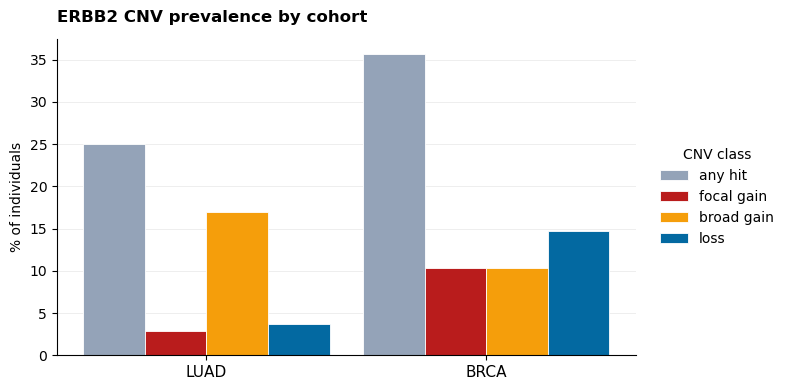

In [13]:
COL_HIT   = "#94A3B8"
COL_FOCAL = "#B91C1C"
COL_BROAD = "#F59E0B"
COL_LOSS  = "#0369A1"

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(prevalence))
width = 0.22

ax.bar(x - 1.5*width, prevalence["ERBB2_hit_pct"],   width,
       label="any hit",     color=COL_HIT,   edgecolor="white", linewidth=0.6)
ax.bar(x - 0.5*width, prevalence["ERBB2_focal_pct"], width,
       label="focal gain",  color=COL_FOCAL, edgecolor="white", linewidth=0.6)
ax.bar(x + 0.5*width, prevalence["ERBB2_broad_pct"], width,
       label="broad gain",  color=COL_BROAD, edgecolor="white", linewidth=0.6)
ax.bar(x + 1.5*width, prevalence["ERBB2_loss_pct"],  width,
       label="loss",        color=COL_LOSS,  edgecolor="white", linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(prevalence["cohort"], fontsize=11)
ax.set_ylabel("% of individuals")
ax.set_title("ERBB2 CNV prevalence by cohort", loc="left", fontweight="bold", pad=12)
ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="CNV class",
)
ax.grid(axis="y", alpha=0.25, linestyle="-", linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Kaplan-Meier curves, side by side

Stratifying by `ERBB2_focal_gain` rather than `ERBB2_gain_hit` is the more
clinically meaningful contrast and is what shows the strongest BRCA signal.

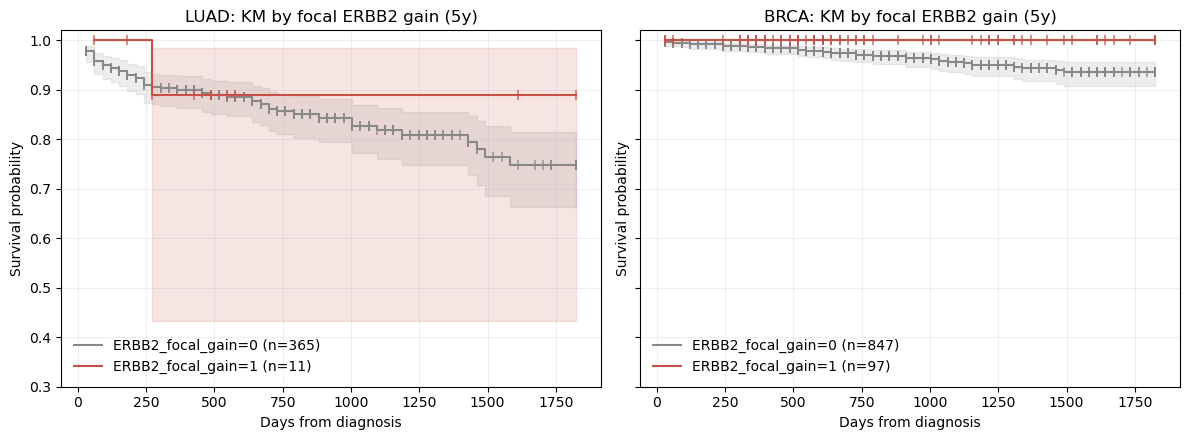

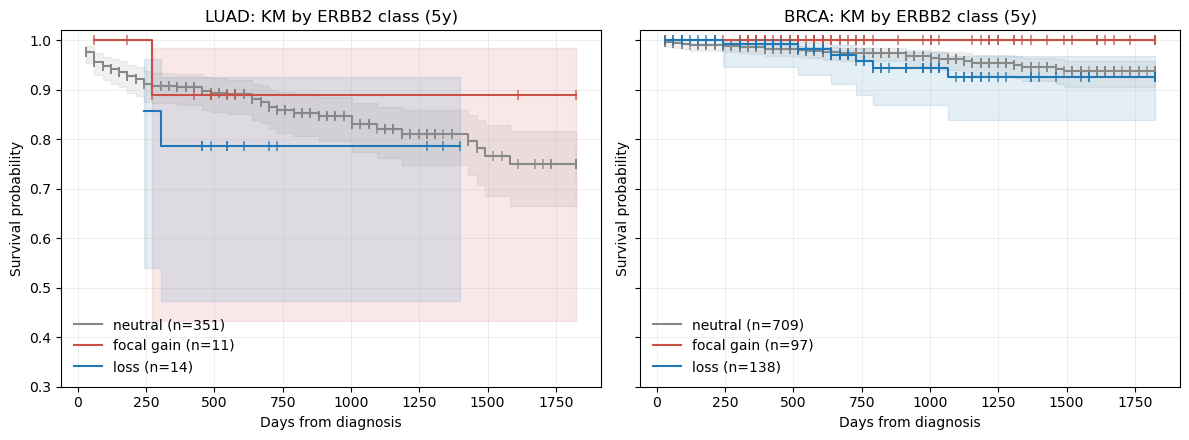

In [14]:
def _add_censor_ticks(ax, sub_time, sub_event, km_time, km_surv, color):
    """Mark censoring times as small vertical ticks on a KM curve."""
    censor_t = sub_time[~sub_event]
    if len(censor_t) == 0:
        return
    # KM is a right-continuous step function: surv value at t is the last event-time value <= t
    idx = np.searchsorted(km_time, censor_t, side="right") - 1
    idx = np.clip(idx, 0, len(km_surv) - 1)
    surv_at = km_surv[idx]
    ax.plot(censor_t, surv_at, marker="|", linestyle="None",
            color=color, markersize=7, markeredgewidth=1.1, alpha=0.85)

def km_plot(ax, df, group_col, title, time_col="time", event_col="event"):
    for value, color, lbl in [(0, "#888", f"{group_col}=0"), (1, "#C75146", f"{group_col}=1")]:
        sub = df[df[group_col] == value]
        if len(sub) < 5:
            continue
        sub_t = sub[time_col].astype(float).values
        sub_e = sub[event_col].astype(bool).values
        time, surv, conf_int = kaplan_meier_estimator(sub_e, sub_t, conf_type="log-log")
        ax.step(time, surv, where="post", color=color, label=f"{lbl} (n={len(sub)})")
        ax.fill_between(time, conf_int[0], conf_int[1], alpha=0.15, step="post", color=color)
        _add_censor_ticks(ax, sub_t, sub_e, time, surv, color)
    ax.set_xlabel("Days from diagnosis")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0.3, 1.02)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="lower left")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, df) in zip(axes, cohort_dfs.items()):
    km_plot(ax, df, "ERBB2_focal_gain", f"{name}: KM by focal ERBB2 gain (5y)",
            time_col="time_5y", event_col="event_5y")
plt.tight_layout()
plt.show()

def erbb2_class(row):
    if row["ERBB2_focal_gain"] == 1:
        return "focal_gain"
    if row["ERBB2_loss_hit"] == 1:
        return "loss"
    return "neutral"

GROUP_STYLES = {
    "neutral":    {"color": "#888",    "label": "neutral"},
    "focal_gain": {"color": "#C75146", "label": "focal gain"},
    "loss":       {"color": "#1f77b4", "label": "loss"},
}


def km_plot_multi(ax, df, group_col, title, time_col="time", event_col="event"):
    for level, style in GROUP_STYLES.items():
        sub = df[df[group_col] == level]
        if len(sub) < 5:
            continue
        sub_t = sub[time_col].astype(float).values
        sub_e = sub[event_col].astype(bool).values
        time, surv, conf_int = kaplan_meier_estimator(sub_e, sub_t, conf_type="log-log")
        ax.step(time, surv, where="post", color=style["color"],
                label=f'{style["label"]} (n={len(sub)})')
        ax.fill_between(time, conf_int[0], conf_int[1], alpha=0.12,
                        step="post", color=style["color"])
        _add_censor_ticks(ax, sub_t, sub_e, time, surv, style["color"])
    ax.set_xlabel("Days from diagnosis")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0.3, 1.02)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="lower left")


for name, df in cohort_dfs.items():
    df["ERBB2_class"] = df.apply(erbb2_class, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, df) in zip(axes, cohort_dfs.items()):
    km_plot_multi(ax, df, "ERBB2_class",
                  f"{name}: KM by ERBB2 class (5y)",
                  time_col="time_5y", event_col="event_5y")
plt.tight_layout()
plt.show()

## Cox model with progressive adjustments

Three nested specifications are fitted per cohort to disentangle effects:

1. **Unadjusted, full follow-up:** `ERBB2_gain_hit + ERBB2_loss_hit`
2. **Unadjusted, 5-year truncated:** same predictors, but the outcome is
   right-censored at 5 years (BRCA early-detection lead-time control).
3. **Stage-adjusted, 5-year truncated:** adds `stage_num` to isolate ERBB2
   from stage distribution differences.

`ERBB2_hit` is excluded because it equals `gain OR loss` and is collinear with
the two component predictors. lifelines is used throughout for proper Wald
confidence intervals and p-values.

In [15]:
def fit_cox(df, features, time_col="time", event_col="event", strata=None):
    used = [f for f in features if df[f].std() > 0]
    cols = used + [time_col, event_col] + (strata or [])
    data = df[cols].dropna().copy()

    cph = CoxPHFitter(penalizer=1e-3)
    cph.fit(data, duration_col=time_col, event_col=event_col, strata=strata)

    summ = cph.summary
    out = pd.DataFrame({
        "feature": summ.index.tolist(),
        "coef": summ["coef"].values,
        "hazard_ratio": summ["exp(coef)"].values,
        "hr_lo": summ["exp(coef) lower 95%"].values,
        "hr_hi": summ["exp(coef) upper 95%"].values,
        "p_value": summ["p"].values,
    })
    return cph, out, cph.concordance_index_, len(data)


SPECS = {
    "unadjusted_full":   {"features": ["ERBB2_gain_hit", "ERBB2_loss_hit"], "time": "time",    "event": "event"},
    "unadjusted_5y":     {"features": ["ERBB2_gain_hit", "ERBB2_loss_hit"], "time": "time_5y", "event": "event_5y"},
    "stage_adj_5y":      {"features": ["ERBB2_gain_hit", "ERBB2_loss_hit", "stage_num"],
                           "time": "time_5y", "event": "event_5y"},
}

cox_results = {}   # cohort -> spec_name -> table
cox_summary_rows = []

for cohort_name, df in cohort_dfs.items():
    cox_results[cohort_name] = {}
    for spec_name, spec in SPECS.items():
        try:
            _, table, cidx, n_used = fit_cox(
                df, spec["features"], time_col=spec["time"], event_col=spec["event"]
            )
        except Exception as e:
            print(f"[{cohort_name}/{spec_name}] fit failed: {e}")
            continue
        table["cohort"] = cohort_name
        table["spec"] = spec_name
        table["c_index"] = cidx
        table["n"] = n_used
        cox_results[cohort_name][spec_name] = table
        cox_summary_rows.append(table)
        print(f"\n[{cohort_name} / {spec_name}] n={n_used}, C-index={cidx:.3f}")
        print(table[["feature", "hazard_ratio", "hr_lo", "hr_hi", "p_value"]]
              .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

cox_summary = pd.concat(cox_summary_rows, ignore_index=True) if cox_summary_rows else pd.DataFrame()


[LUAD / unadjusted_full] n=376, C-index=0.544
       feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_gain_hit         1.429  0.778  2.622    0.249
ERBB2_loss_hit         1.733  0.535  5.614    0.359

[LUAD / unadjusted_5y] n=376, C-index=0.544
       feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_gain_hit         1.464  0.796  2.693    0.220
ERBB2_loss_hit         1.744  0.538  5.653    0.354

[LUAD / stage_adj_5y] n=370, C-index=0.624
       feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_gain_hit         1.299  0.701  2.407    0.407
ERBB2_loss_hit         1.515  0.465  4.940    0.491
     stage_num         1.415  1.073  1.867    0.014

[BRCA / unadjusted_full] n=944, C-index=0.555
       feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_gain_hit         0.548  0.219  1.372    0.199
ERBB2_loss_hit         0.712  0.301  1.684    0.439

[BRCA / unadjusted_5y] n=944, C-index=0.557
       feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_gain_hit         0.452  0.143  1.426  

## Forest plot: hazard ratios across cohorts and adjustments

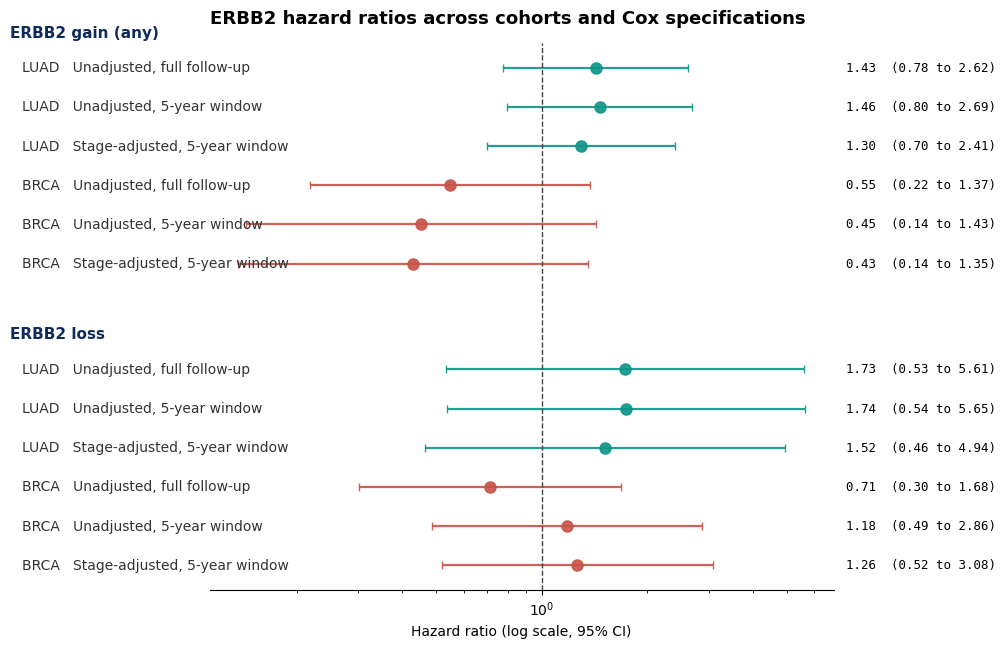

In [16]:
import pandas as pd
from matplotlib.lines import Line2D

# Pretty labels for the raw column/spec names
SPEC_LABELS = {
    "unadjusted_full": "Unadjusted, full follow-up",
    "unadjusted_5y":   "Unadjusted, 5-year window",
    "stage_adj_5y":    "Stage-adjusted, 5-year window",
}
FEATURE_LABELS = {
    "ERBB2_gain_hit":   "ERBB2 gain (any)",
    "ERBB2_loss_hit":   "ERBB2 loss",
    "ERBB2_focal_gain": "ERBB2 focal gain",
    "ERBB2_broad_gain": "ERBB2 broad gain",
}
SPEC_ORDER   = ["unadjusted_full", "unadjusted_5y", "stage_adj_5y"]
COHORT_ORDER = ["LUAD", "BRCA"]

# Keep ERBB2 features only, in a deterministic order: by feature, then cohort, then spec
plot_df = cox_summary[cox_summary["feature"].str.startswith("ERBB2_")].copy()
plot_df["spec_idx"]   = plot_df["spec"].map(lambda s: SPEC_ORDER.index(s) if s in SPEC_ORDER else 99)
plot_df["cohort_idx"] = plot_df["cohort"].map(lambda c: COHORT_ORDER.index(c) if c in COHORT_ORDER else 99)
plot_df["feat_idx"]   = plot_df["feature"].map(lambda f: list(FEATURE_LABELS).index(f) if f in FEATURE_LABELS else 99)
plot_df = plot_df.sort_values(["feat_idx", "cohort_idx", "spec_idx"]).reset_index(drop=True)

# Compute y positions per row, with a gap between feature groups (for visual separation)
features_in_order = [f for f in FEATURE_LABELS if f in plot_df["feature"].unique()]
header_y, row_y = [], {}
y = 0.0
GROUP_GAP = 0.8
for feat in features_in_order:
    header_y.append((y, FEATURE_LABELS[feat]))
    y += 0.9
    for idx in plot_df.index[plot_df["feature"] == feat]:
        row_y[idx] = y
        y += 1.0
    y += GROUP_GAP
plot_df["y"] = plot_df.index.map(row_y)

# Plot
fig, ax = plt.subplots(figsize=(12, 0.45 * len(plot_df) + 0.6 * len(features_in_order) + 1))
fig.subplots_adjust(left=0.34, right=0.86, top=0.82, bottom=0.10)

for _, r in plot_df.iterrows():
    color = COHORTS[r["cohort"]]["color"]
    ax.errorbar(
        r["hazard_ratio"], r["y"],
        xerr=[[max(r["hazard_ratio"] - r["hr_lo"], 1e-9)],
              [max(r["hr_hi"]   - r["hazard_ratio"], 1e-9)]],
        fmt="o", color=color, ecolor=color, alpha=0.9,
        capsize=3, markersize=8, linewidth=1.6,
    )

# Section headers (left of the plot, in axis-fraction x)
for hy, text in header_y:
    ax.text(-0.32, hy, text,
            transform=ax.get_yaxis_transform(),
            ha="left", va="center",
            fontsize=11, fontweight="bold", color="#0F2A5C")

# Row labels: cohort name plus pretty spec name
for _, r in plot_df.iterrows():
    label = f"{r['cohort']}   {SPEC_LABELS[r['spec']]}"
    ax.text(-0.30, r["y"], label,
            transform=ax.get_yaxis_transform(),
            ha="left", va="center", fontsize=10, color="#333")

# Right-side numeric annotations: HR (CI) only
for _, r in plot_df.iterrows():
    hr_txt = f"{r['hazard_ratio']:.2f}  ({r['hr_lo']:.2f} to {r['hr_hi']:.2f})"
    ax.text(1.02, r["y"], hr_txt,
            transform=ax.get_yaxis_transform(),
            ha="left", va="center", fontsize=9, family="monospace")

ax.axvline(1.0, linestyle="--", color="#444", linewidth=1)
ax.set_yticks([])
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio (log scale, 95% CI)")
ax.set_title("ERBB2 hazard ratios across cohorts and Cox specifications",
             fontsize=13, fontweight="bold", loc="left", pad=14)
ax.invert_yaxis()  # top-down reading order
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(alpha=0.3, axis="x")

# Cohort colour legend, parked above the axes so it cannot overlap any row
legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=COHORTS[c]["color"], markersize=9,
           label=COHORTS[c]["label"])
    for c in COHORT_ORDER if c in plot_df["cohort"].unique()
]

plt.show()

## Focal vs broad gain: Cox model on the clinically relevant subgroup

Replacing `ERBB2_gain_hit` with `ERBB2_focal_gain` and `ERBB2_broad_gain`
asks whether short, high-amplitude amplifications (the HER2-positive events)
behave differently from long, arm-level gains.

In [17]:
focal_results = []
for cohort_name, df in cohort_dfs.items():
    try:
        _, table, cidx, n_used = fit_cox(
            df,
            ["ERBB2_focal_gain", "ERBB2_broad_gain", "ERBB2_loss_hit", "stage_num"],
            time_col="time_5y", event_col="event_5y",
        )
    except Exception as e:
        print(f"[{cohort_name}] focal-vs-broad fit failed: {e}")
        continue
    table["cohort"] = cohort_name
    table["c_index"] = cidx
    table["n"] = n_used
    focal_results.append(table)
    print(f"\n[{cohort_name}] focal vs broad, stage-adjusted, 5y. n={n_used}, C-index={cidx:.3f}")
    print(table[["feature", "hazard_ratio", "hr_lo", "hr_hi", "p_value"]]
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

focal_summary = pd.concat(focal_results, ignore_index=True) if focal_results else pd.DataFrame()


[LUAD] focal vs broad, stage-adjusted, 5y. n=370, C-index=0.623
         feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_focal_gain         0.877  0.121  6.350    0.896
ERBB2_broad_gain         1.354  0.714  2.568    0.353
  ERBB2_loss_hit         1.521  0.467  4.961    0.486
       stage_num         1.401  1.059  1.854    0.018

[BRCA] focal vs broad, stage-adjusted, 5y. n=929, C-index=0.714
         feature  hazard_ratio  hr_lo  hr_hi  p_value
ERBB2_focal_gain         0.064  0.002  2.019    0.118
ERBB2_broad_gain         0.859  0.263  2.801    0.800
  ERBB2_loss_hit         1.276  0.523  3.113    0.592
       stage_num         2.748  1.693  4.462    0.000


## Pooled model with cohort by ERBB2 interaction

Fitting one Cox model on the merged, 5-year truncated, stage-adjusted data
with an interaction term tests whether the ERBB2 focal-gain effect on hazard
differs significantly between LUAD and BRCA.

In [18]:
pooled = pd.concat(cohort_dfs.values(), ignore_index=True)
pooled["is_BRCA"] = (pooled["cohort"] == "BRCA").astype(int)
pooled["focal_x_BRCA"] = pooled["ERBB2_focal_gain"] * pooled["is_BRCA"]

POOLED_FEATURES = ["ERBB2_focal_gain", "ERBB2_broad_gain", "ERBB2_loss_hit",
                   "is_BRCA", "focal_x_BRCA", "stage_num"]

pooled_data = pooled[POOLED_FEATURES + ["time_5y", "event_5y"]].dropna()

cph_pool = CoxPHFitter(penalizer=1e-3)
cph_pool.fit(pooled_data, duration_col="time_5y", event_col="event_5y")

pooled_table = (cph_pool.summary[
    ["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "z", "p"]
].rename(columns={
    "exp(coef)": "hazard_ratio",
    "exp(coef) lower 95%": "hr_lo",
    "exp(coef) upper 95%": "hr_hi",
}))
pooled_table

,coef,hazard_ratio,hr_lo,hr_hi,z,p
covariate,,,,,,
ERBB2_focal_gain,-0.235175,0.790432,0.104642,5.970662,-0.227956,8.196803e-01
ERBB2_broad_gain,0.117788,1.125005,0.644156,1.964799,0.414022,6.788576e-01
ERBB2_loss_hit,0.258169,1.294557,0.635743,2.636096,0.711545,4.767465e-01
is_BRCA,-1.797059,0.165786,0.105256,0.261124,-7.752951,8.978100e-15
focal_x_BRCA,-2.539093,0.078938,0.001787,3.487203,-1.313695,1.889488e-01
stage_num,0.503310,1.654187,1.307719,2.092449,4.197291,2.701269e-05


- `ERBB2_focal_gain` is the hazard ratio for a focal ERBB2 amplification in the *reference* cohort (LUAD, stage-adjusted, 5y window).
- `is_BRCA` is the baseline hazard ratio for a BRCA patient with no ERBB2 alteration, at the same stage.
- `focal_x_BRCA` is the **interaction**: the multiplicative difference in the focal ERBB2 gain effect between BRCA and LUAD. The associated `z` and `p` columns formalise the comparison.

## Discrimination summary

In [19]:
rows = []
for cohort_name, specs in cox_results.items():
    for spec_name, table in specs.items():
        rows.append({"cohort": cohort_name, "spec": spec_name,
                     "n": table["n"].iloc[0], "c_index": table["c_index"].iloc[0]})
for table in focal_results:
    rows.append({"cohort": table["cohort"].iloc[0], "spec": "focal_vs_broad_5y_stage",
                 "n": table["n"].iloc[0], "c_index": table["c_index"].iloc[0]})
rows.append({"cohort": "POOLED", "spec": "focal_interaction_5y_stage",
             "n": len(pooled_data), "c_index": cph_pool.concordance_index_})
pd.DataFrame(rows)

,cohort,spec,n,c_index
0,LUAD,unadjusted_full,376,0.544142
1,LUAD,unadjusted_5y,376,0.544379
2,LUAD,stage_adj_5y,370,0.623746
3,BRCA,unadjusted_full,944,0.555076
4,BRCA,unadjusted_5y,944,0.557497
5,BRCA,stage_adj_5y,929,0.697981
6,LUAD,focal_vs_broad_5y_stage,370,0.622543
7,BRCA,focal_vs_broad_5y_stage,929,0.714279
8,POOLED,focal_interaction_5y_stage,1299,0.783762
